In [ ]:
from google.colab import drive
import os
import sys

drive.mount('/content/drive')

!pip install transformers accelerate -q
!pip install torchmetrics -q
!pip install "segmentation-models-pytorch @ git+https://github.com/qubvel/segmentation_models.pytorch" -q
!pip install albumentations -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# CELDA 1: Configuración

# Rutas
DRIVE_ROOT = "/content/drive/MyDrive/plant_segmentation"
CKPT_PATH = os.path.join(DRIVE_ROOT, "ckpts_3models_resize")
os.makedirs(CKPT_PATH, exist_ok=True)
DATA_ROOT = DRIVE_ROOT

# Parámetros Globales
DATASET_TYPE = "dead" # 'cwt' o 'dead'
INVENTARY_NAME = "data_inventary.csv"
IMG_SIZE = 512
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 70
SEED = 42313988

# Configuración Multi-Clase
if DATASET_TYPE == 'dead':
    LABEL2ID_DATASET = {'dead': 0, 'dead_cut': 1, 'noise': 2}
    ID2LABEL_MODEL = {0: 'background', 1: 'dead', 2: 'dead_cut'}
else:
    LABEL2ID_DATASET = {'normal': 0, 'normal_cut': 1, 'noise': 2}
    ID2LABEL_MODEL = {0: 'background', 1: 'normal', 2: 'normal_cut'}

LABEL2ID_MODEL = {v: k for k, v in ID2LABEL_MODEL.items()}
NUM_CLASSES = len(ID2LABEL_MODEL)

print(f"✅ Configuración lista para 3 modelos. Dataset: {DATASET_TYPE}. Seed: {SEED}")

✅ Configuración lista para 3 modelos. Dataset: dead. Seed: 42313988


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from PIL import Image
import pandas as pd
import numpy as np
import re
import random
import cv2
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torchmetrics import JaccardIndex
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torch.cuda.amp import GradScaler, autocast

In [ ]:
# CELDA 2:  Augmentations y Utils


# 1. Reproducibilidad
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

# 2. Augmentations (VOLVEMOS A RESIZE)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_augs = A.Compose([
    # Resize inicial (Volvemos a la estrategia original)
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),

    # Geométricos
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # Deformación Elástica (Mantenemos esto, ayuda mucho en biología)
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),

    # Color
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),

    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

val_augs = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

# 3. Post-procesamiento
def clean_mask_prediction(mask_np, min_size=30):
    cleaned_mask = mask_np.copy()
    for class_id in [1, 2]:
        binary_class_mask = (mask_np == class_id).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_class_mask, connectivity=8)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] < min_size:
                cleaned_mask[labels == i] = 0
    return cleaned_mask

# 4. Joint Loss
class JointLoss(nn.Module):
    def __init__(self, dice_weight=0.5, focal_weight=0.5):
        super(JointLoss, self).__init__()
        self.dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.focal_loss = smp.losses.FocalLoss(mode='multiclass')
        self.dw = dice_weight
        self.fw = focal_weight

    def forward(self, y_pred, y_true):
        return self.dw * self.dice_loss(y_pred, y_true) + self.fw * self.focal_loss(y_pred, y_true)

/tmp/ipython-input-997242143.py:31: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),


In [ ]:
# CELDA 3: Dataset y DataLoaders
def get_multiclass_target_np(masks, labels, size):
    target_mask = np.zeros(size, dtype=np.uint8)
    for mask_path, label_id in zip(masks, labels):
        if label_id in [0, 1]:
            mask_pil = Image.open(mask_path)
            # Aseguramos que la máscara tenga el tamaño de la imagen original antes del resize
            if mask_pil.size != (size[1], size[0]): # PIL es (W, H)
                 mask_pil = mask_pil.resize((size[1], size[0]), resample=Image.NEAREST)

            mask_np = np.array(mask_pil)
            pixels_to_update = mask_np > 0
            target_mask[pixels_to_update] = label_id + 1
    return target_mask

class PlantDataset(Dataset):
    def __init__(self, root, folder, inventary_name, label2id, transform=None):
        self.root = root
        self.folder = folder
        self.transform = transform
        self._label2id = label2id
        self.idx_table = pd.read_csv(os.path.join(self.root, self.folder, inventary_name))
        self.images, self.masks, self.labels = [], [], []

        files_in_folder = sorted(os.listdir(os.path.join(self.root, self.folder, 'original')),
                               key=lambda x: (int(re.findall(r'\d+', x.split('_')[0])[0]),
                                              int(re.findall(r'\d+', x.split('_')[1])[0])))

        for img_name in files_in_folder:
            id_original_img = int(re.findall(r'\d+', img_name.split('_')[0])[0])
            id_after_split = int(re.findall(r'\d+', img_name.split('_')[1])[0])
            mask_idx_row = self.idx_table[(self.idx_table['id orginal img'] == id_original_img) & (self.idx_table['id after split'] == id_after_split)]
            if mask_idx_row.empty: continue

            self.images.append(os.path.join(self.root, self.folder, 'original', img_name))
            mask_idx = mask_idx_row['id']._values[0]
            mask_dir = os.path.join(self.root, self.folder, 'original_labeled', str(mask_idx))

            current_masks, current_labels = [], []
            if os.path.exists(mask_dir):
                get_tag = lambda x: x.split('/')[-1].split('-')[-2]
                for m_name in os.listdir(mask_dir):
                    tag = get_tag(m_name)
                    if tag in self._label2id:
                        current_masks.append(os.path.join(mask_dir, m_name))
                        current_labels.append(self._label2id[tag])
            self.masks.append(current_masks)
            self.labels.append(current_labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image_pil = Image.open(image_path).convert('RGB')
        w, h = image_pil.size
        image_np = np.array(image_pil)

        mask_np = get_multiclass_target_np(self.masks[idx], self.labels[idx], size=(h, w))

        if self.transform:
            augmented = self.transform(image=image_np, mask=mask_np)
            image_np = augmented['image']
            mask_np = augmented['mask']

        return image_np, mask_np.long()

# Generar DataLoaders
dataset_base = PlantDataset(DATA_ROOT, DATASET_TYPE, INVENTARY_NAME, label2id=LABEL2ID_DATASET, transform=None)
val_pct = 0.15
val_size = int(len(dataset_base) * val_pct)
train_size = len(dataset_base) - val_size

set_seed(SEED)
train_indices, val_indices = random_split(range(len(dataset_base)), [train_size, val_size])

train_ds = PlantDataset(DATA_ROOT, DATASET_TYPE, INVENTARY_NAME, label2id=LABEL2ID_DATASET, transform=train_augs)
val_ds = PlantDataset(DATA_ROOT, DATASET_TYPE, INVENTARY_NAME, label2id=LABEL2ID_DATASET, transform=val_augs)

train_subset = Subset(train_ds, train_indices)
val_subset = Subset(val_ds, val_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"📊 Dataset Split: Train={len(train_subset)}, Val={len(val_subset)}")

📊 Dataset Split: Train=34, Val=5


In [ ]:
# CELDA 4: Definición de los 3 Modelos
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def get_model(model_name):
    if model_name == "unet_resnet":
        print("🏗️ Creando Modelo 1: U-Net (ResNet34)...")
        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=NUM_CLASSES,
        )
    elif model_name == "unet_transformer":
        print("🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...")
        # Este es el reemplazo de Swin-Unet. Encoder Transformer + Decoder U-Net.
        model = smp.Unet(
            encoder_name="mit_b2",
            encoder_weights="imagenet",
            in_channels=3,
            classes=NUM_CLASSES,
        )
    elif model_name == "segformer_fpn":
        print("🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...")
        # Usamos FPN con MiT-B2, que es arquitecturalmente lo más cercano
        # a SegFormer en esta librería (Encoder Jerárquico + Decoder Ligero).
        model = smp.FPN(
            encoder_name="mit_b2",
            encoder_weights="imagenet",
            in_channels=3,
            classes=NUM_CLASSES,
        )
    return model.to(device)

In [ ]:
# CELDA 5: Motor de Entrenamiento
def train_engine(model, model_alias, train_dl, val_dl, epochs=EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    loss_fn = JointLoss(dice_weight=0.5, focal_weight=0.5).to(device)
    scaler = GradScaler()
    jaccard = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro', ignore_index=0).to(device)

    best_iou = 0.0
    history = {'train_loss': [], 'val_iou_clean': []}

    print(f"\n🚀 Entrenando: {model_alias}...")

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        loop = tqdm(train_dl, desc=f"Ep {epoch+1}/{epochs}", leave=False)

        for xb, yb in loop:
            xb, yb = xb.to(device), yb.to(device)
            with autocast():
                outputs = model(xb)
                loss = loss_fn(outputs, yb)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        scheduler.step()
        avg_train_loss = train_loss / len(train_dl)
        history['train_loss'].append(avg_train_loss)

        # Validación
        model.eval()
        iou_clean_accum = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)

                # Post-procesamiento
                preds_clean = preds.clone()
                for i in range(preds.shape[0]):
                    mask_cpu = preds[i].cpu().numpy().astype(np.uint8)
                    mask_clean = clean_mask_prediction(mask_cpu, min_size=30)
                    preds_clean[i] = torch.from_numpy(mask_clean).to(device)

                iou_clean_accum += jaccard(preds_clean, yb).item()

        avg_iou_clean = iou_clean_accum / len(val_dl)
        history['val_iou_clean'].append(avg_iou_clean)

        print(f"   Loss: {avg_train_loss:.4f} | mIoU (Clean): {avg_iou_clean:.4f}")

        if avg_iou_clean > best_iou:
            best_iou = avg_iou_clean
            torch.save(model.state_dict(), os.path.join(CKPT_PATH, f"best_{model_alias}_{DATASET_TYPE}.pth"))
            print(f"   💾 Guardado ({best_iou:.4f})")

    return history

In [ ]:
# CELDA 6: Ejecución de los 3 Modelos
# 1. SegFormer (FPN MiT)
model_3 = get_model("segformer_fpn")
hist_3 = train_engine(model_3, "segformer_fpn", train_loader, val_loader)

🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...

🚀 Entrenando: segformer_fpn...


/tmp/ipython-input-1441790333.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/70:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipython-input-1441790333.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Loss: 1.6153 | mIoU (Clean): 0.0386
   💾 Guardado (0.0386)


...

   Loss: 0.0801 | mIoU (Clean): 0.6099


Ep 69/70:   0%|          | 0/5 [00:00<?, ?it/s]

   Loss: 0.0810 | mIoU (Clean): 0.6097


Ep 70/70:   0%|          | 0/5 [00:00<?, ?it/s]

   Loss: 0.0825 | mIoU (Clean): 0.6095


In [ ]:
# 2. U-Net (ResNet)
model_1 = get_model("unet_resnet")
hist_1 = train_engine(model_1, "unet_resnet", train_loader, val_loader)

🏗️ Creando Modelo 1: U-Net (ResNet34)...

🚀 Entrenando: unet_resnet...


/tmp/ipython-input-1441790333.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/70:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipython-input-1441790333.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Loss: 1.1436 | mIoU (Clean): 0.1730
   💾 Guardado (0.1730)


...

   Loss: 0.3346 | mIoU (Clean): 0.5152


Ep 69/70:   0%|          | 0/5 [00:00<?, ?it/s]

   Loss: 0.3349 | mIoU (Clean): 0.5179


Ep 70/70:   0%|          | 0/5 [00:00<?, ?it/s]

   Loss: 0.3386 | mIoU (Clean): 0.5180


In [ ]:
# 3. U-Net (Transformer MiT)
model_2 = get_model("unet_transformer")
hist_2 = train_engine(model_2, "unet_transformer", train_loader, val_loader)

🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...

🚀 Entrenando: unet_transformer...


/tmp/ipython-input-1441790333.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/70:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipython-input-1441790333.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Loss: 0.7750 | mIoU (Clean): 0.3285
   💾 Guardado (0.3285)


...

   Loss: 0.2834 | mIoU (Clean): 0.6379


Ep 69/70:   0%|          | 0/5 [00:00<?, ?it/s]

   Loss: 0.2838 | mIoU (Clean): 0.6351


Ep 70/70:   0%|          | 0/5 [00:00<?, ?it/s]

   Loss: 0.2834 | mIoU (Clean): 0.6322



📊 Generando estadísticas finales...
🏗️ Creando Modelo 1: U-Net (ResNet34)...


Stats:   0%|          | 0/1 [00:00<?, ?it/s]

🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...


Stats:   0%|          | 0/1 [00:00<?, ?it/s]

🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...


Stats:   0%|          | 0/1 [00:00<?, ?it/s]


📝 Tabla Comparativa:


,Model,Mean mIoU,Std Dev,Paper Format
0,U-Net (ResNet34),0.604912,0.173183,0.605 ± 0.173
1,U-Net (Transformer),0.681583,0.147621,0.682 ± 0.148
2,SegFormer (FPN),0.637443,0.076746,0.637 ± 0.077


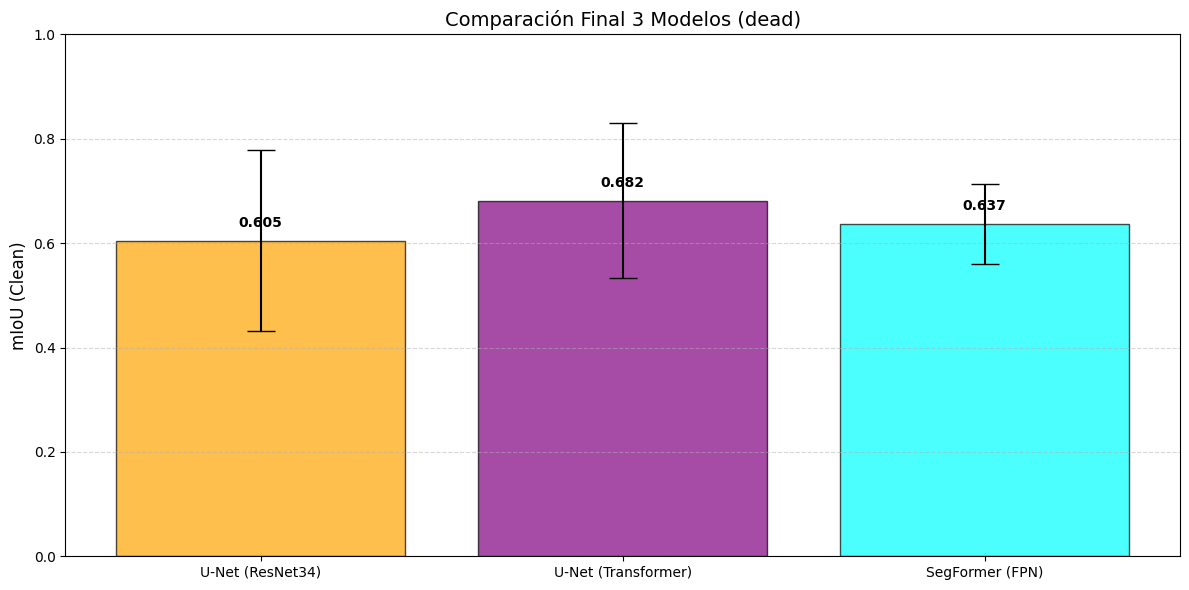

In [ ]:
# CELDA 7: Estadísticas Finales y Gráficos (Para 3 Modelos)

def get_detailed_stats(model, loader, device, num_classes):
    model.eval()
    iou_per_image = []
    metric = JaccardIndex(task="multiclass", num_classes=num_classes, average='macro', ignore_index=0).to(device)

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Stats", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1)

            preds_clean = preds.clone()
            for i in range(preds.shape[0]):
                mask_cpu = preds[i].cpu().numpy().astype(np.uint8)
                mask_clean = clean_mask_prediction(mask_cpu, min_size=30)
                preds_clean[i] = torch.from_numpy(mask_clean).to(device)

                single_iou = metric(preds_clean[i].unsqueeze(0), yb[i].unsqueeze(0))
                iou_per_image.append(single_iou.item())
    return np.array(iou_per_image)

print("\n📊 Generando estadísticas finales...")

# Cargar pesos
m1 = get_model("unet_resnet")
m1.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_resnet_{DATASET_TYPE}.pth")))
ious_1 = get_detailed_stats(m1, val_loader, device, NUM_CLASSES)

m2 = get_model("unet_transformer")
m2.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_transformer_{DATASET_TYPE}.pth")))
ious_2 = get_detailed_stats(m2, val_loader, device, NUM_CLASSES)

m3 = get_model("segformer_fpn")
m3.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_segformer_fpn_{DATASET_TYPE}.pth")))
ious_3 = get_detailed_stats(m3, val_loader, device, NUM_CLASSES)

# Tabla
stats = {
    "Model": ["U-Net (ResNet34)", "U-Net (Transformer)", "SegFormer (FPN)"],
    "Mean mIoU": [np.mean(ious_1), np.mean(ious_2), np.mean(ious_3)],
    "Std Dev": [np.std(ious_1), np.std(ious_2), np.std(ious_3)]
}
df_stats = pd.DataFrame(stats)
df_stats["Paper Format"] = df_stats.apply(lambda x: f"{x['Mean mIoU']:.3f} ± {x['Std Dev']:.3f}", axis=1)

print("\n📝 Tabla Comparativa:")
display(df_stats)
df_stats.to_csv(os.path.join(CKPT_PATH, f"final_stats_3models_{DATASET_TYPE}.csv"), index=False)

# Gráfico
plt.figure(figsize=(12, 6))
colors = ['orange', 'purple', 'cyan']
bars = plt.bar(df_stats["Model"], df_stats["Mean mIoU"], yerr=df_stats["Std Dev"], capsize=10, color=colors, alpha=0.7, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.title(f"Comparación Final 3 Modelos ({DATASET_TYPE})", fontsize=14)
plt.ylabel("mIoU (Clean)", fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_PATH, f"barplot_3models_{DATASET_TYPE}.png"), dpi=300)
plt.show()

📈 Generando Gráficos de Entrenamiento...


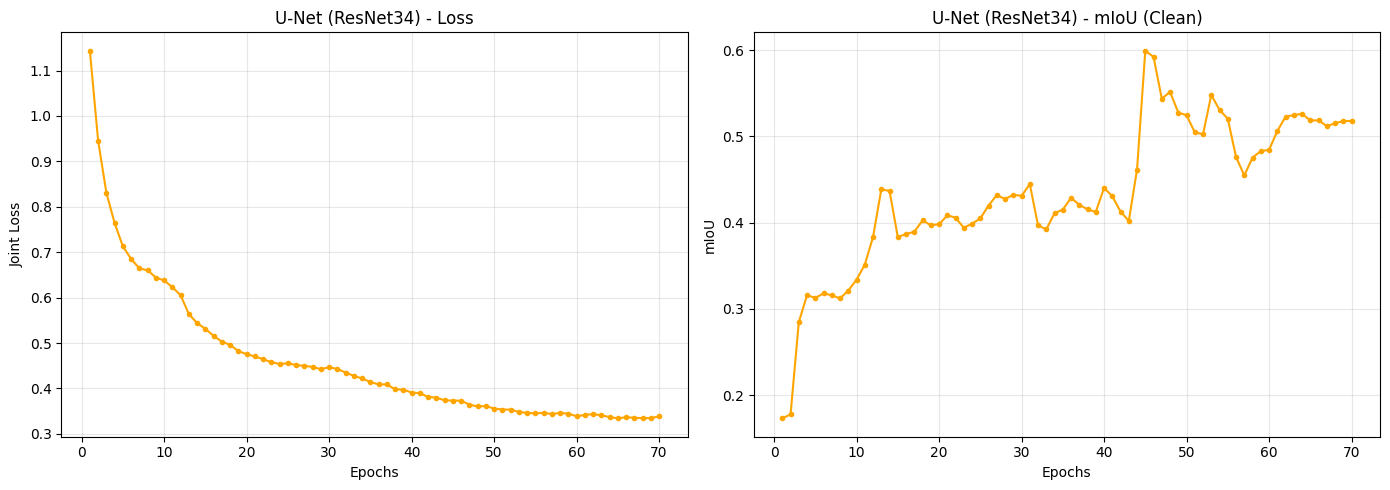

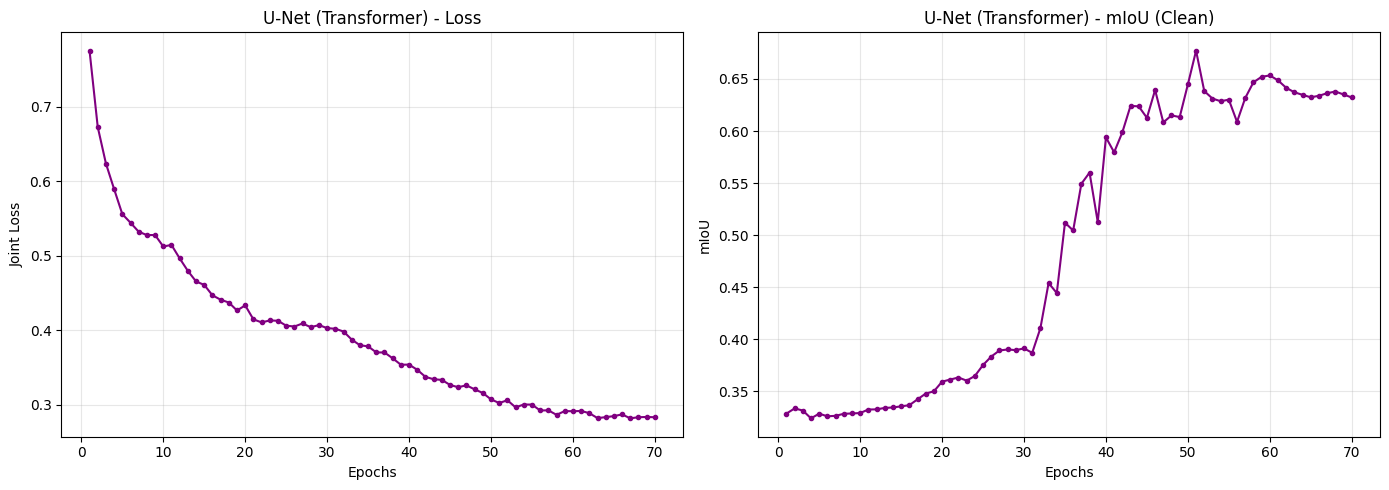

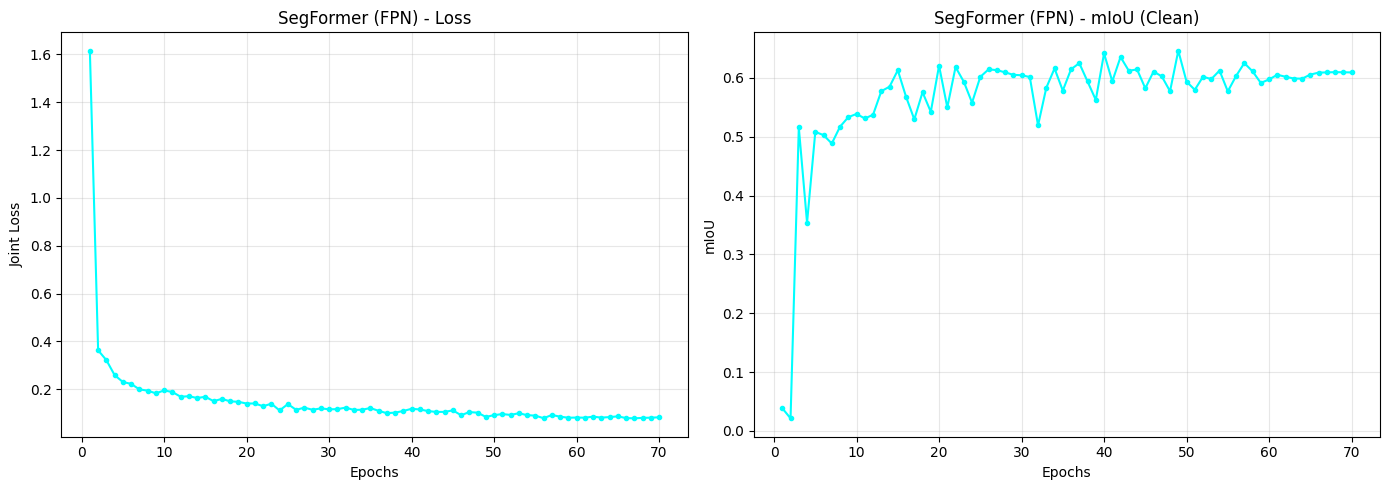

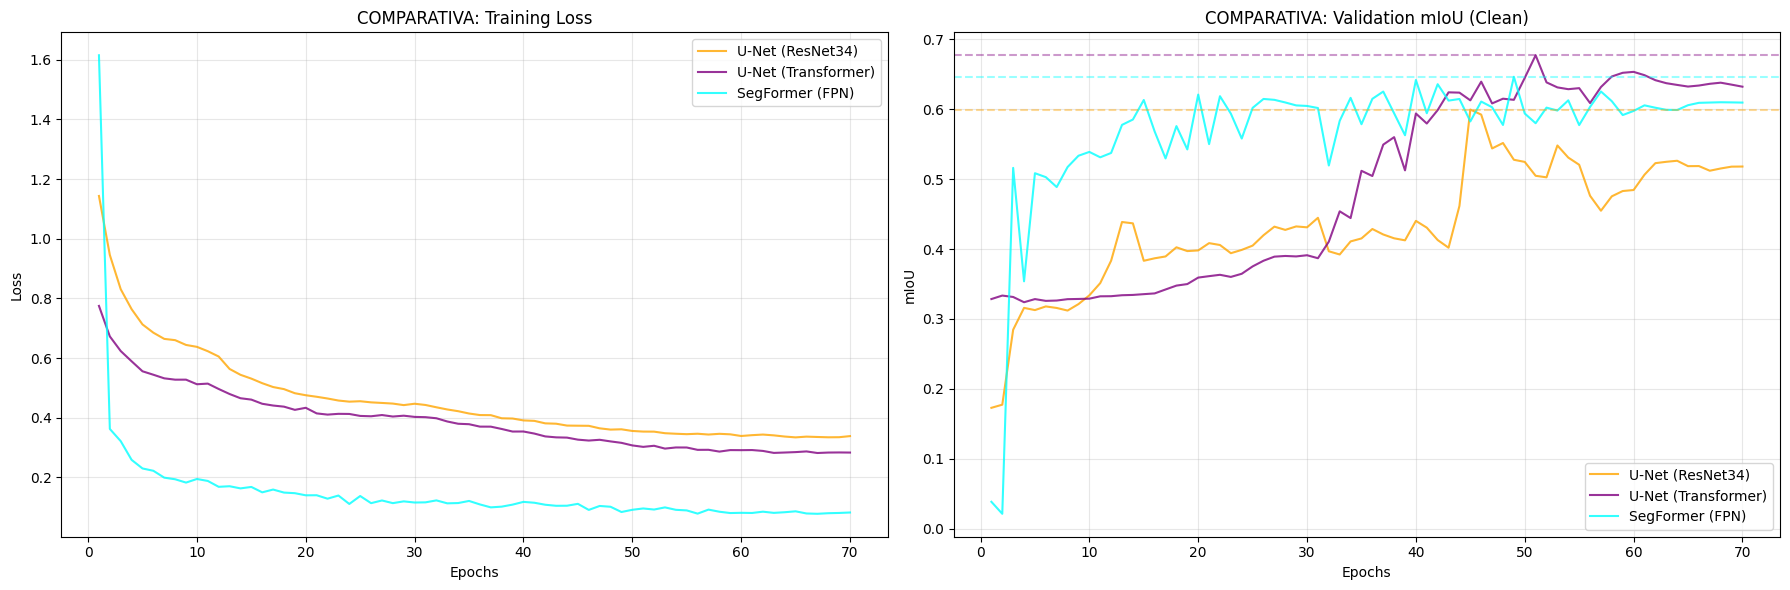

In [ ]:
# --- CELDA 8: Gráficos de Entrenamiento (Individuales y Comparativos) ---
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilos
colors = {'unet_resnet': 'orange', 'unet_transformer': 'purple', 'segformer_fpn': 'cyan'}
labels = {'unet_resnet': 'U-Net (ResNet34)', 'unet_transformer': 'U-Net (Transformer)', 'segformer_fpn': 'SegFormer (FPN)'}

def plot_single_model(history, model_key):
    """Grafica Loss y mIoU para un solo modelo"""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, history['train_loss'], 'o-', color=colors[model_key], label='Train Loss', markersize=3)
    ax1.set_title(f"{labels[model_key]} - Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Joint Loss")
    ax1.grid(True, alpha=0.3)

    # mIoU
    ax2.plot(epochs, history['val_iou_clean'], 'o-', color=colors[model_key], label='Val mIoU (Clean)', markersize=3)
    ax2.set_title(f"{labels[model_key]} - mIoU (Clean)")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("mIoU")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_comparison(h1, h2, h3):
    """Grafica las curvas de los 3 modelos superpuestas"""
    epochs = range(1, len(h1['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # --- COMPARACIÓN LOSS ---
    ax1.plot(epochs, h1['train_loss'], label=labels['unet_resnet'], color=colors['unet_resnet'], alpha=0.8)
    ax1.plot(epochs, h2['train_loss'], label=labels['unet_transformer'], color=colors['unet_transformer'], alpha=0.8)
    ax1.plot(epochs, h3['train_loss'], label=labels['segformer_fpn'], color=colors['segformer_fpn'], alpha=0.8)
    ax1.set_title("COMPARATIVA: Training Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- COMPARACIÓN mIoU ---
    ax2.plot(epochs, h1['val_iou_clean'], label=labels['unet_resnet'], color=colors['unet_resnet'], alpha=0.8)
    ax2.plot(epochs, h2['val_iou_clean'], label=labels['unet_transformer'], color=colors['unet_transformer'], alpha=0.8)
    ax2.plot(epochs, h3['val_iou_clean'], label=labels['segformer_fpn'], color=colors['segformer_fpn'], alpha=0.8)

    # Marcar máximos
    max_1 = max(h1['val_iou_clean'])
    max_2 = max(h2['val_iou_clean'])
    max_3 = max(h3['val_iou_clean'])

    ax2.axhline(max_1, color=colors['unet_resnet'], linestyle='--', alpha=0.4)
    ax2.axhline(max_2, color=colors['unet_transformer'], linestyle='--', alpha=0.4)
    ax2.axhline(max_3, color=colors['segformer_fpn'], linestyle='--', alpha=0.4)

    ax2.set_title("COMPARATIVA: Validation mIoU (Clean)")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("mIoU")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("📈 Generando Gráficos de Entrenamiento...")

# 1. Gráficos Individuales
plot_single_model(hist_1, 'unet_resnet')
plot_single_model(hist_2, 'unet_transformer')
plot_single_model(hist_3, 'segformer_fpn')

# 2. Gráfico Comparativo Final
plot_comparison(hist_1, hist_2, hist_3)

/tmp/ipython-input-3377718863.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(mean=[-m/s for m, s in zip(mean, std)], std=[1/s for s in std], max_pixel_value=1.0, always_apply=True),


📥 Cargando modelos óptimos...
🏗️ Creando Modelo 1: U-Net (ResNet34)...
🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...
🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...
🖼️ Generando visualizaciones para 5 imágenes...


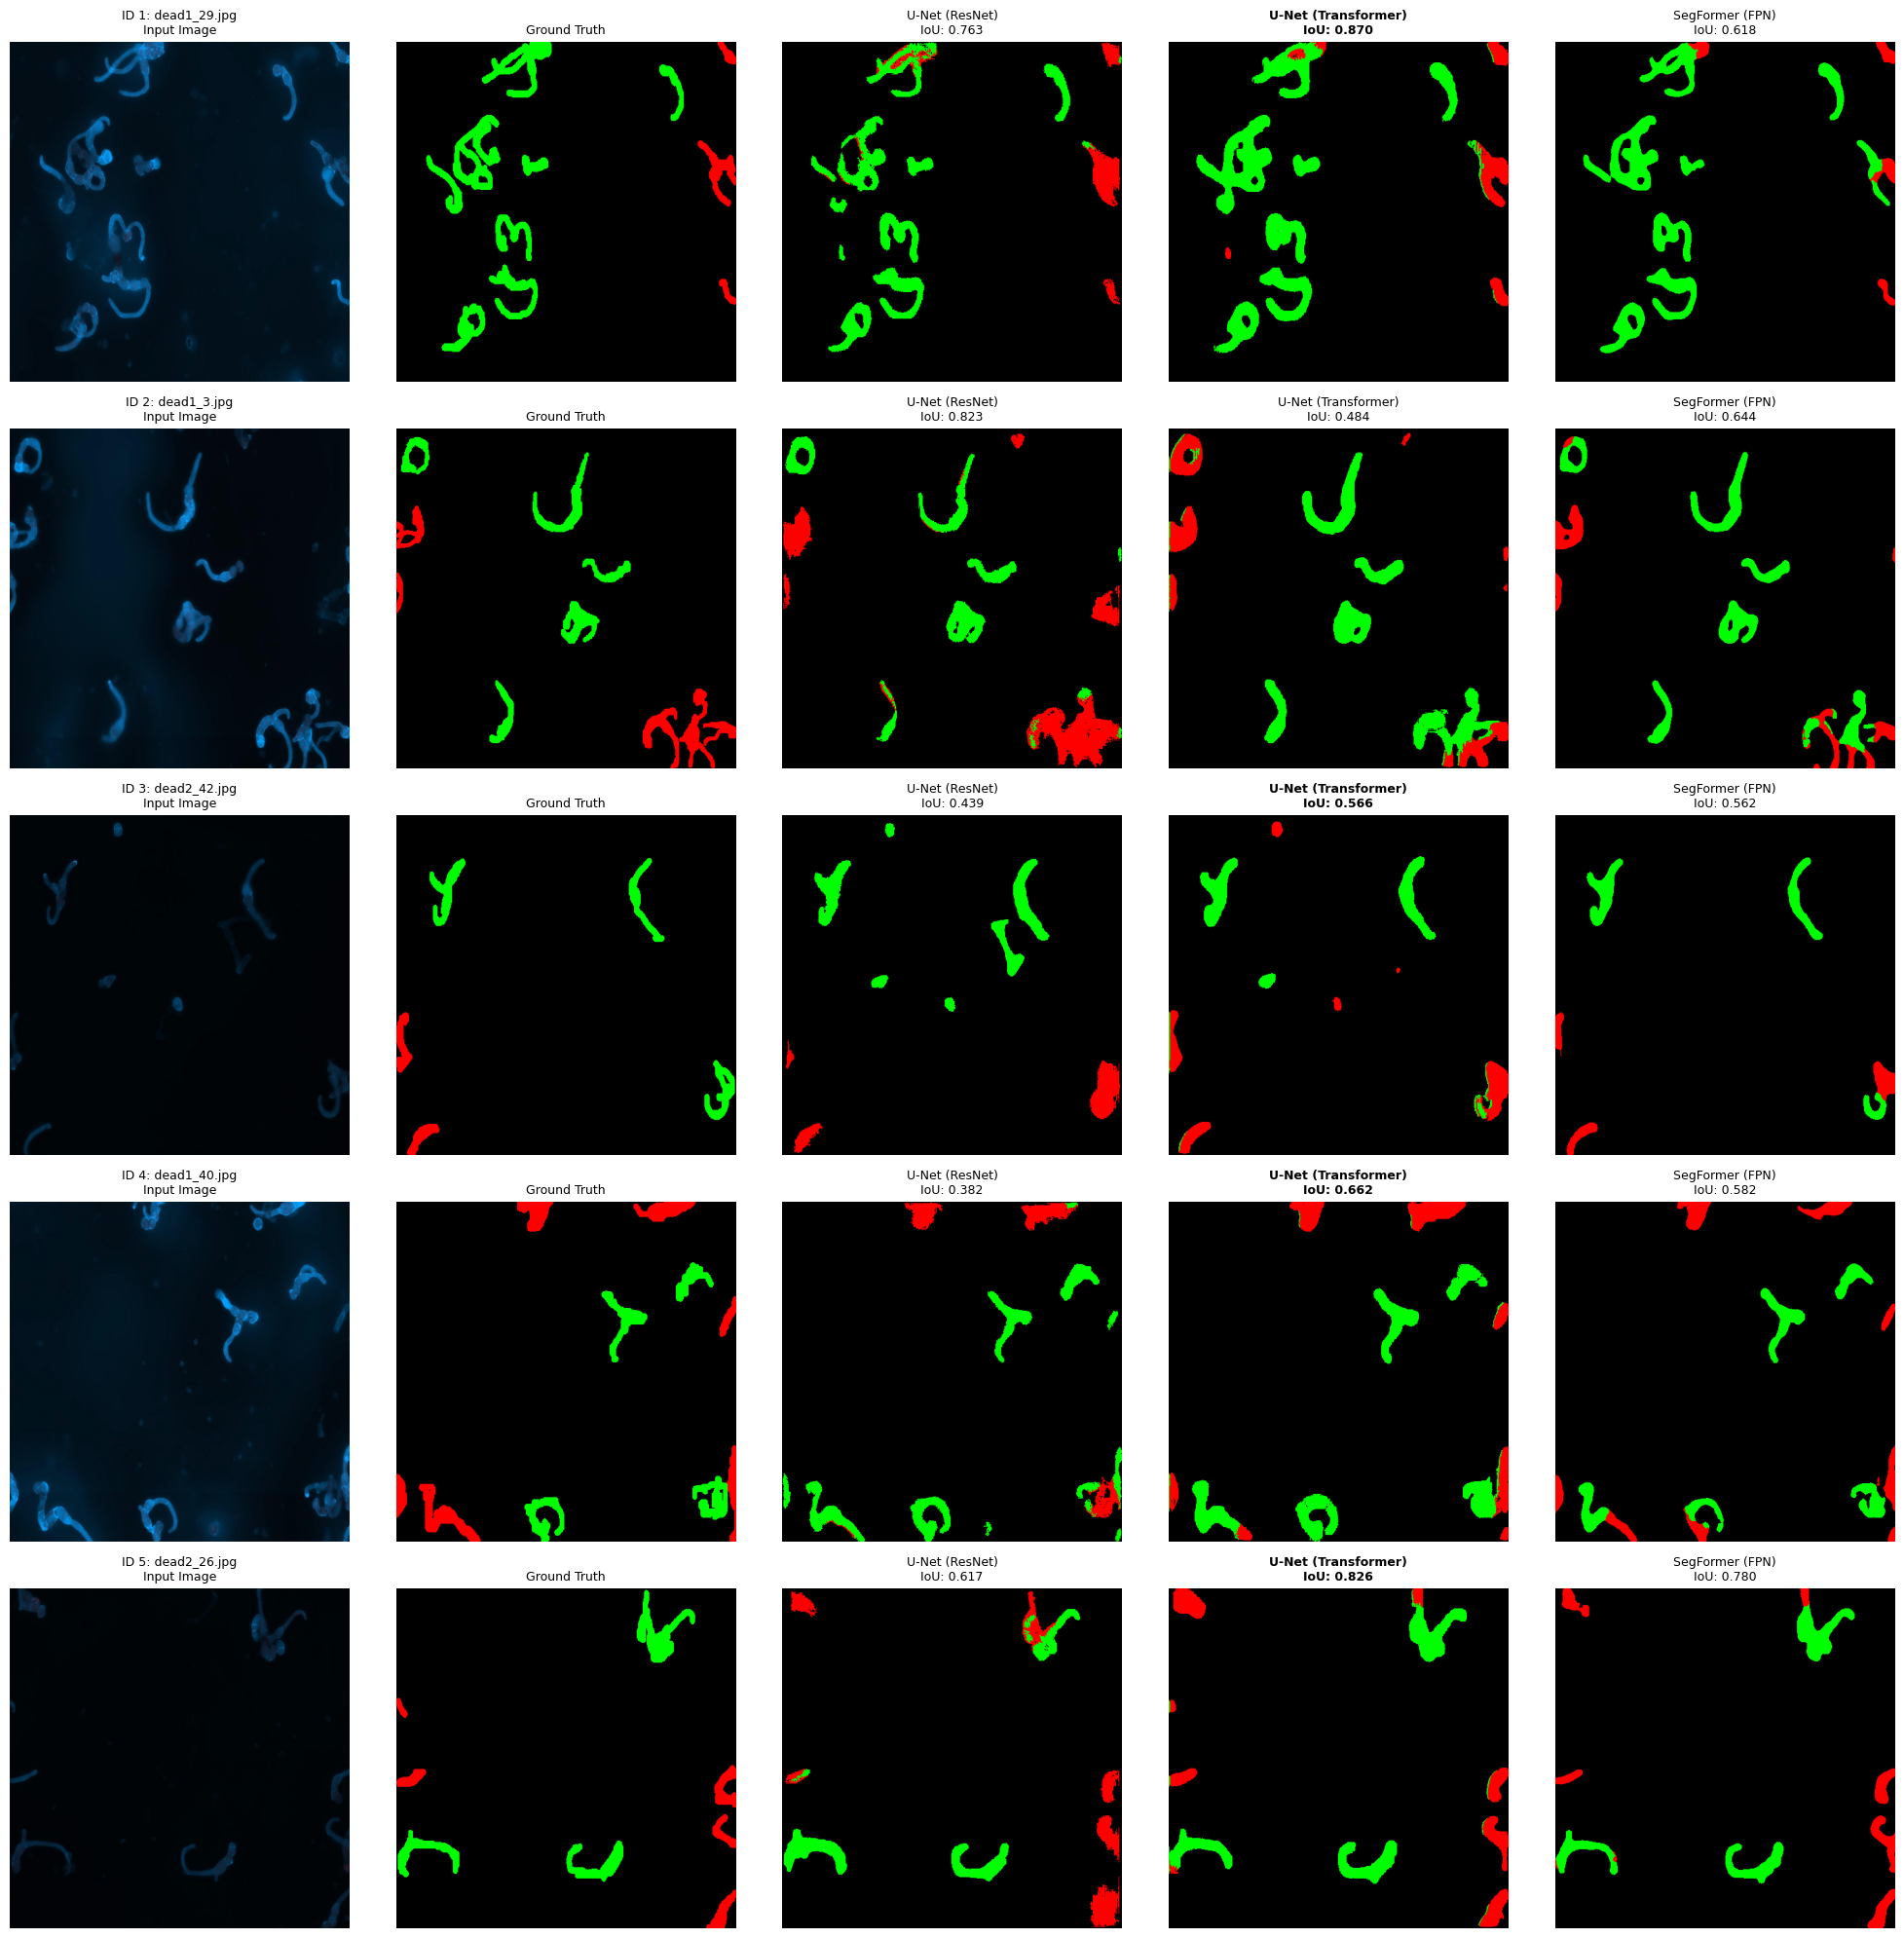


📊 TABLA DE RESULTADOS POR IMAGEN:


,ID,Filename,IoU U-Net (ResNet),IoU U-Net (Transf),IoU SegFormer (FPN),Winner
0,1,dead1_29.jpg,0.762927,0.869780,0.618444,U-Net (Transf)
1,2,dead1_3.jpg,0.823192,0.484072,0.643652,U-Net (ResNet)
2,3,dead2_42.jpg,0.439325,0.566222,0.562483,U-Net (Transf)
3,4,dead1_40.jpg,0.381812,0.661910,0.582369,U-Net (Transf)
4,5,dead2_26.jpg,0.617306,0.825929,0.780266,U-Net (Transf)


✅ Resultados detallados guardados en: /content/drive/MyDrive/plant_segmentation/ckpts_3models_resize/detailed_results_by_image_dead.csv
✅ Imagen comparativa guardada en: /content/drive/MyDrive/plant_segmentation/ckpts_3models_resize/visual_comparison_dead.png


In [ ]:
# --- CELDA 9: Visualización Detallada y Tabla de Resultados ---

# 1. Configuración de Visualización
# Inversa de la normalización para mostrar la imagen original correctamente
inv_normalize = A.Compose([
    A.Normalize(mean=[-m/s for m, s in zip(mean, std)], std=[1/s for s in std], max_pixel_value=1.0, always_apply=True),
])

# Mapa de colores para máscaras (0=Negro, 1=Verde, 2=Rojo/Magenta)
# Ajusta estos colores si prefieres otros.
# Formato: [R, G, B]
palette = np.array([
    [0, 0, 0],       # 0: Background (Negro)
    [0, 255, 0],     # 1: Normal/Dead (Verde)
    [255, 0, 0]      # 2: Cut (Rojo)
], dtype=np.uint8)

def mask_to_rgb(mask_tensor):
    """Convierte tensor (H,W) de clases a numpy (H,W,3) RGB"""
    mask_np = mask_tensor.cpu().numpy().astype(np.uint8)
    return palette[mask_np]

def predict_and_clean(model, xb):
    """Realiza inferencia y limpieza"""
    model.eval()
    with torch.no_grad():
        out = model(xb)
        pred = torch.argmax(out, dim=1)[0] # Tomar primer elemento batch
        # Limpieza
        mask_cpu = pred.cpu().numpy().astype(np.uint8)
        mask_clean = clean_mask_prediction(mask_cpu, min_size=30)
        return torch.from_numpy(mask_clean).to(device)

# 2. Cargar Mejores Modelos
print("📥 Cargando modelos óptimos...")
model_1 = get_model("unet_resnet")
model_1.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_resnet_{DATASET_TYPE}.pth")))

model_2 = get_model("unet_transformer")
model_2.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_transformer_{DATASET_TYPE}.pth")))

model_3 = get_model("segformer_fpn")
model_3.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_segformer_fpn_{DATASET_TYPE}.pth")))

# 3. Crear DataLoader individual para visualización (Batch Size = 1)
# Usamos val_subset que ya tiene los índices correctos definidos anteriormente
val_loader_single = DataLoader(val_subset, batch_size=1, shuffle=False)

# 4. Loop de Evaluación y Plotting
results_data = []
metric = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro', ignore_index=0).to(device)

print(f"🖼️ Generando visualizaciones para {len(val_subset)} imágenes...")

# Ajusta esto si son demasiadas imágenes y quieres ver solo las primeras 10
LIMIT_IMAGES = 20

# Configurar subplots (Filas = Imágenes, Columnas = 5)
num_imgs_to_show = min(len(val_subset), LIMIT_IMAGES)
fig, axes = plt.subplots(num_imgs_to_show, 5, figsize=(20, 4 * num_imgs_to_show))

for idx, (xb, yb) in enumerate(val_loader_single):
    if idx >= num_imgs_to_show: break

    xb, yb = xb.to(device), yb.to(device)

    # Obtener nombre del archivo original
    original_idx = val_indices[idx]
    filename = os.path.basename(dataset_base.images[original_idx])

    # Predicciones
    p1 = predict_and_clean(model_1, xb)
    p2 = predict_and_clean(model_2, xb)
    p3 = predict_and_clean(model_3, xb)

    # Calcular IoU individual
    iou_1 = metric(p1.unsqueeze(0), yb).item()
    iou_2 = metric(p2.unsqueeze(0), yb).item()
    iou_3 = metric(p3.unsqueeze(0), yb).item()

    # Guardar datos
    results_data.append({
        "ID": idx + 1,
        "Filename": filename,
        "IoU U-Net (ResNet)": iou_1,
        "IoU U-Net (Transf)": iou_2,
        "IoU SegFormer (FPN)": iou_3,
        "Winner": ["U-Net (ResNet)", "U-Net (Transf)", "SegFormer"][np.argmax([iou_1, iou_2, iou_3])]
    })

    # --- PLOTTING ---
    ax = axes[idx] if num_imgs_to_show > 1 else axes

    # 1. Imagen Original
    img_viz = inv_normalize(image=xb[0].permute(1,2,0).cpu().numpy())['image']
    ax[0].imshow(img_viz)
    ax[0].set_title(f"ID {idx+1}: {filename}\nInput Image", fontsize=9)
    ax[0].axis('off')

    # 2. Ground Truth
    ax[1].imshow(mask_to_rgb(yb[0]))
    ax[1].set_title("Ground Truth", fontsize=9)
    ax[1].axis('off')

    # 3. Modelo 1
    ax[2].imshow(mask_to_rgb(p1))
    ax[2].set_title(f"U-Net (ResNet)\nIoU: {iou_1:.3f}", fontsize=9)
    ax[2].axis('off')

    # 4. Modelo 2
    ax[3].imshow(mask_to_rgb(p2))
    ax[3].set_title(f"U-Net (Transformer)\nIoU: {iou_2:.3f}", fontsize=9, fontweight='bold' if iou_2 >= max(iou_1, iou_3) else 'normal')
    ax[3].axis('off')

    # 5. Modelo 3
    ax[4].imshow(mask_to_rgb(p3))
    ax[4].set_title(f"SegFormer (FPN)\nIoU: {iou_3:.3f}", fontsize=9, fontweight='bold' if iou_3 >= max(iou_1, iou_2) else 'normal')
    ax[4].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_PATH, f"visual_comparison_{DATASET_TYPE}.png"), dpi=150)
plt.show()

# 5. Generar y Guardar Tabla
df_res = pd.DataFrame(results_data)
csv_path = os.path.join(CKPT_PATH, f"detailed_results_by_image_{DATASET_TYPE}.csv")
df_res.to_csv(csv_path, index=False)

print("\n📊 TABLA DE RESULTADOS POR IMAGEN:")
# Estilo de color para la tabla (resaltar ganador)
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

display(df_res.style.apply(highlight_max, subset=["IoU U-Net (ResNet)", "IoU U-Net (Transf)", "IoU SegFormer (FPN)"], axis=1))

print(f"✅ Resultados detallados guardados en: {csv_path}")
print(f"✅ Imagen comparativa guardada en: {os.path.join(CKPT_PATH, f'visual_comparison_{DATASET_TYPE}.png')}")